In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', '{:.2f}'.format)

# 1. Data Preparation

## 1.1 Loading and cleaning both the datasets
gas_data = Exports of Goods and Services (WB_WDI_NE_EXP_GNFS_ZS.csv) \
sva_data = Services, Value Added (services_,_value_addes.csv)

In [8]:
gas_data = pd.read_csv("exports_of_goods_and_services.csv")
sva_data = pd.read_csv("services_,_value_addes.csv")

print("Datasets loaded successfully.")
print(f"Services dataset: {sva_data.shape}")
print(f"Exports dataset: {gas_data.shape}")

Datasets loaded successfully.
Services dataset: (10765, 41)
Exports dataset: (11390, 41)


In [9]:
gas_data.sample(5)

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,TIME_PERIOD,OBS_VALUE,AGG_METHOD,UNIT_TYPE,DECIMALS,DATABASE_ID,TIME_FORMAT,UNIT_MULT,OBS_STATUS,OBS_CONF,FREQ_LABEL,REF_AREA_LABEL,INDICATOR_LABEL,SEX_LABEL,AGE_LABEL,URBANISATION_LABEL,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
1868,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SAU,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2022,35.99,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Saudi Arabia,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
7800,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MYS,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2015,69.45,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Malaysia,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4992,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,LMC,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,1963,11.25,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Lower middle income,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
6089,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,FRO,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2013,55.44,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Faroe Islands,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
7804,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BEN,WB_WDI_NE_EXP_GNFS_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2021,20.92,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Benin,Exports of goods and services (% of GDP),Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


In [10]:
sva_data.sample(5)

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,TIME_PERIOD,OBS_VALUE,AGG_METHOD,UNIT_TYPE,DECIMALS,DATABASE_ID,TIME_FORMAT,UNIT_MULT,OBS_STATUS,OBS_CONF,FREQ_LABEL,REF_AREA_LABEL,INDICATOR_LABEL,SEX_LABEL,AGE_LABEL,URBANISATION_LABEL,UNIT_MEASURE_LABEL,COMP_BREAKDOWN_1_LABEL,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
5870,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SWZ,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2013,48.72,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Eswatini,"Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
6919,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,KNA,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2018,63.35,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,St. Kitts and Nevis,"Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
10364,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MLT,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,1972,33.84,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Malta,"Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
5049,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ARG,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,1966,40.12,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Argentina,"Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
5754,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MOZ,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,_Z,_Z,_Z,2014,47.44,_Z,RATIO,2,WB_WDI,P1Y,0,A,PU,Annual,Mozambique,"Services, value added (% of GDP)",Total,All age ranges or no breakdown by age,Total,Percentage of GDP,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


In [11]:
# These are the columns required for analysis

analysis_columns = [
    "REF_AREA",
    "REF_AREA_LABEL",
    "INDICATOR",
    "INDICATOR_LABEL",
    "TIME_PERIOD",
    "OBS_VALUE",
    "UNIT_MEASURE_LABEL",
    "UNIT_TYPE_LABEL"
]

print("Analysis columns created successfully.")

Analysis columns created successfully.


### Choosing the analysis columns

Both datasets contain many columns that repeat metadata about the source, formatting, or reporting structure rather than the actual data. To keep the datasets focused on what matters for analysis, we selected only the columns that describe the country, the indicator being measured, the year, the value itself, and the unit of measurement:

- REF_AREA and REF_AREA_LABEL identify which country the row belongs to
- INDICATOR and INDICATOR_LABEL describe what is being measured
- TIME_PERIOD is the year the value applies to
- OBS_VALUE is the actual figure being analysed
- UNIT_MEASURE_LABEL and UNIT_TYPE_LABEL describe what kind of measurement the value represents (for example, percentage of GDP)

Keeping INDICATOR_LABEL and UNIT_MEASURE_LABEL, even though every remaining row shares the same value, also served a practical purpose, it let us confirm that both datasets were consistently measured in percentage of GDP before comparing them, and it helped catch that the Services Value Added dataset initially contained mixed currencies and growth rates that needed to be filtered out.

In [12]:
# Filtering datasets to South Africa
south_africa_exports = gas_data[gas_data["REF_AREA"] == "ZAF"].copy()
south_africa_services = sva_data[sva_data["REF_AREA"] == "ZAF"].copy()

In [13]:
# Keeping only the relevant analysis columns

exports_analysis = south_africa_exports[analysis_columns].copy()
services_analysis = south_africa_services[analysis_columns].copy()

print("Exports analysis:", exports_analysis.shape)
print("Services analysis:", services_analysis.shape)

Exports analysis: (66, 8)
Services analysis: (66, 8)


In [14]:
# Standardising column names
rename_columns = {
    "REF_AREA": "Country_Code",
    "REF_AREA_LABEL": "Country",
    "INDICATOR": "Indicator_Code",
    "INDICATOR_LABEL": "Indicator",
    "TIME_PERIOD": "Year",
    "OBS_VALUE": "Value",
    "UNIT_MEASURE_LABEL": "Unit",
    "UNIT_TYPE_LABEL": "Unit_Type"
}

exports_analysis.rename(columns=rename_columns, inplace=True)
services_analysis.rename(columns=rename_columns, inplace=True)

In [15]:
# Sorting the year chronologically
exports_analysis.sort_values("Year", inplace=True)
services_analysis.sort_values("Year", inplace=True)

In [16]:
# Reseting indexes
exports_analysis.reset_index(drop=True, inplace=True)
services_analysis.reset_index(drop=True, inplace=True)

print("Data preparation completed successfully.")

Data preparation completed successfully.


In [17]:
# Verifying the indicators and measurement units

indicator_check = pd.DataFrame({
    "Dataset": [
        "Exports",
        "Services Value Added"
    ],
    "Country": [
        exports_analysis["Country"].iloc[0],
        services_analysis["Country"].iloc[0]
    ],
    "Indicator": [
        exports_analysis["Indicator"].iloc[0],
        services_analysis["Indicator"].iloc[0]
    ],
    "Unit": [
        exports_analysis["Unit"].iloc[0],
        services_analysis["Unit"].iloc[0]
    ]
})

display(indicator_check)

,Dataset,Country,Indicator,Unit
0,Exports,South Africa,Exports of goods and services (% of GDP),Percentage of GDP
1,Services Value Added,South Africa,"Services, value added (% of GDP)",Percentage of GDP


## 1.2. Data Quality and Validation

Before conducting statistical analysis, the datasets are checked for
completeness, duplicate country-year observations, temporal coverage and
consistent measurement units.

These checks ensure that the analysis is based on valid and comparable
observations.

In [18]:
# Data quality summary

quality_summary = pd.DataFrame({
    "Dataset": [
        "Exports of Goods and Services",
        "Services Value Added"
    ],
    "Rows": [
        len(exports_analysis),
        len(services_analysis)
    ],
    "Columns": [
        exports_analysis.shape[1],
        services_analysis.shape[1]
    ],
    "Missing Values": [
        exports_analysis["Value"].isna().sum(),
        services_analysis["Value"].isna().sum()
    ],
    "Duplicate Country-Year Records": [
        exports_analysis.duplicated(["Country_Code", "Year"]).sum(),
        services_analysis.duplicated(["Country_Code", "Year"]).sum()
    ],
    "Minimum Year": [
        exports_analysis["Year"].min(),
        services_analysis["Year"].min()
    ],
    "Maximum Year": [
        exports_analysis["Year"].max(),
        services_analysis["Year"].max()
    ]
})

display(quality_summary)

,Dataset,Rows,Columns,Missing Values,Duplicate Country-Year Records,Minimum Year,Maximum Year
0,Exports of Goods and Services,66,8,0,0,1960,2025
1,Services Value Added,66,8,0,0,1960,2025


### Data Quality Insight

Both South African datasets contain 66 annual observations covering 1960 to 2025. There are no missing values in the observation field and no duplicate country-year records in either dataset. Both indicators are measured as a percentage of GDP, which makes them directly comparable in the subsequent analysis.

The cleaning process also reduced the original 41-column datasets to eight analysis-relevant variables, removing metadata that is not required for the statistical analysis while retaining the information necessary to identify the country, indicator, year, value and measurement unit.

## 1.3 Descriptive Statistics

Descriptive statistics are used to summarise the distribution and variability
of South Africa's exports of goods and services and services value added as
percentages of GDP.

The analysis considers the mean, median, standard deviation, minimum,
maximum, quartiles and range. Comparing these statistics helps identify the
typical contribution of each indicator to GDP and the extent to which the
indicators have varied between 1960 and 2025.

In [19]:
# Calculating descriptive statistics for both indicators

descriptive_stats = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "25th Percentile",
        "75th Percentile",
        "Maximum",
        "Range"
    ],
    "Exports (% GDP)": [
        exports_analysis["Value"].count(),
        exports_analysis["Value"].mean(),
        exports_analysis["Value"].median(),
        exports_analysis["Value"].std(),
        exports_analysis["Value"].min(),
        exports_analysis["Value"].quantile(0.25),
        exports_analysis["Value"].quantile(0.75),
        exports_analysis["Value"].max(),
        exports_analysis["Value"].max() - exports_analysis["Value"].min()
    ],
    "Services Value Added (% GDP)": [
        services_analysis["Value"].count(),
        services_analysis["Value"].mean(),
        services_analysis["Value"].median(),
        services_analysis["Value"].std(),
        services_analysis["Value"].min(),
        services_analysis["Value"].quantile(0.25),
        services_analysis["Value"].quantile(0.75),
        services_analysis["Value"].max(),
        services_analysis["Value"].max() - services_analysis["Value"].min()
    ]
})

display(descriptive_stats.round(2))

,Statistic,Exports (% GDP),Services Value Added (% GDP)
0,Count,66.00,66.00
1,Mean,25.15,57.48
2,Median,25.09,57.13
3,Standard Deviation,3.81,5.33
4,Minimum,18.40,46.89
5,25th Percentile,22.05,53.03
6,75th Percentile,27.67,62.74
7,Maximum,33.54,64.61
8,Range,15.14,17.72


In [20]:
# Comparing variability

exports_std = exports_analysis["Value"].std()
services_std = services_analysis["Value"].std()

if exports_std > services_std:
    more_variable = "Exports of goods and services"
else:
    more_variable = "Services value added"

print(f"Exports standard deviation: {exports_std:.2f}")
print(f"Services value added standard deviation: {services_std:.2f}")
print(f"More variable indicator: {more_variable}")

Exports standard deviation: 3.81
Services value added standard deviation: 5.33
More variable indicator: Services value added


In [21]:
# Comparing mean and median

exports_mean_median_difference = (
    exports_analysis["Value"].mean() -
    exports_analysis["Value"].median()
)

services_mean_median_difference = (
    services_analysis["Value"].mean() -
    services_analysis["Value"].median()
)

print(
    f"Exports mean-median difference: "
    f"{exports_mean_median_difference:.2f}"
)

print(
    f"Services value added mean-median difference: "
    f"{services_mean_median_difference:.2f}"
)

Exports mean-median difference: 0.06
Services value added mean-median difference: 0.35


In [22]:
# Identifying the highest and lowest observations

extreme_values = pd.DataFrame({
    "Indicator": [
        "Exports of goods and services",
        "Exports of goods and services",
        "Services value added",
        "Services value added"
    ],
    "Observation": [
        "Highest",
        "Lowest",
        "Highest",
        "Lowest"
    ],
    "Year": [
        exports_analysis.loc[exports_analysis["Value"].idxmax(), "Year"],
        exports_analysis.loc[exports_analysis["Value"].idxmin(), "Year"],
        services_analysis.loc[services_analysis["Value"].idxmax(), "Year"],
        services_analysis.loc[services_analysis["Value"].idxmin(), "Year"]
    ],
    "Value (% GDP)": [
        exports_analysis["Value"].max(),
        exports_analysis["Value"].min(),
        services_analysis["Value"].max(),
        services_analysis["Value"].min()
    ]
})

display(extreme_values.round(2))

,Indicator,Observation,Year,Value (% GDP)
0,Exports of goods and services,Highest,2022,33.54
1,Exports of goods and services,Lowest,1970,18.40
2,Services value added,Highest,2020,64.61
3,Services value added,Lowest,1980,46.89


In [23]:
# Calculating the coefficience of variation

exports_cv = (
    exports_analysis["Value"].std() /
    exports_analysis["Value"].mean()
) * 100

services_cv = (
    services_analysis["Value"].std() /
    services_analysis["Value"].mean()
) * 100

cv_comparison = pd.DataFrame({
    "Indicator": [
        "Exports of goods and services",
        "Services value added"
    ],
    "Mean": [
        exports_analysis["Value"].mean(),
        services_analysis["Value"].mean()
    ],
    "Standard Deviation": [
        exports_analysis["Value"].std(),
        services_analysis["Value"].std()
    ],
    "Coefficient of Variation (%)": [
        exports_cv,
        services_cv
    ]
})

display(cv_comparison.round(2))

,Indicator,Mean,Standard Deviation,Coefficient of Variation (%)
0,Exports of goods and services,25.15,3.81,15.14
1,Services value added,57.48,5.33,9.26


### Insight

Services value added averaged 57.48% of GDP, more than double the export figure of 25.15%. This shows services are the dominant contributor to South Africa's economic output, while exports make up a much smaller share.

Looking at variation, services value added has a higher standard deviation (5.33 vs 3.81), so it swings more in absolute terms. But once each indicator is compared against its own average using the coefficient of variation, exports are actually the more volatile of the two (15.14% vs 9.26%). This means exports fluctuate more relative to their own typical size, even though services move more in raw percentage points.

The mean and median are close for both indicators (a difference of 0.06 for exports, 0.35 for services), so neither indicator is being pulled far off-centre by a small number of extreme years, both are fairly evenly distributed across the period.

Exports peaked at 33.54% in 2022 and hit their lowest point at 18.40% in 1970. Services value added peaked at 64.61% in 2020 and was at its lowest, 46.89%, in 1980. The 2020 peak for services lines up with the global shift toward services and remote economic activity during that period, and the 2022 export peak may reflect a post-pandemic trade recovery, both years worth flagging for a closer look in the time-series visualisation.

# 2. Numerical Analysis

Numerical analysis is performed using NumPy to calculate and compare key numerical measures for South Africa's exports of goods and services and services value added.

## 2.1 Creating NumPy Arrays

The cleaned observation values are converted from Pandas Series into NumPy arrays. This allows numerical operations to be performed efficiently using NumPy.

In [24]:

services_numeric = services_analysis[
    services_analysis["Unit"] == "Percentage change per annum"
].dropna(subset=["Value"]).copy()

# Convert cleaned values into NumPy arrays
exports_array = exports_analysis["Value"].dropna().to_numpy()
services_array = services_numeric["Value"].to_numpy()

# Display basic array information
print("Exports array shape:", exports_array.shape)
print("Services array shape:", services_array.shape)

print("Exports observations:", exports_array.size)
print("Services observations:", services_array.size)

print("Services unit used:")
print(services_numeric["Unit"].unique())

Exports array shape: (66,)
Services array shape: (0,)
Exports observations: 66
Services observations: 0
Services unit used:
[]


## 2.2 Numerical Calculations

NumPy is used to calculate key statistical measures for South Africa's exports and services value-added data. These measures summarise the central tendency, spread, and range of the observations.

In [25]:

# Exports calculations
exports_mean = np.mean(exports_array)
exports_median = np.median(exports_array)
exports_std = np.std(exports_array)
exports_min = np.min(exports_array)
exports_max = np.max(exports_array)

# Services calculations
services_mean = np.mean(services_array)
services_median = np.median(services_array)
services_std = np.std(services_array)
services_min = np.min(services_array)
services_max = np.max(services_array)

# Display results
print("EXPORTS")
print(f"Mean: {exports_mean:.2f}")
print(f"Median: {exports_median:.2f}")
print(f"Standard Deviation: {exports_std:.2f}")
print(f"Minimum: {exports_min:.2f}")
print(f"Maximum: {exports_max:.2f}")

print("SERVICES VALUE ADDED")
print(f"Mean: {services_mean:.2f}")
print(f"Median: {services_median:.2f}")
print(f"Standard Deviation: {services_std:.2f}")
print(f"Minimum: {services_min:.2f}")
print(f"Maximum: {services_max:.2f}")

ValueError: zero-size array to reduction operation minimum which has no identity

## 2.3 Array Reshaping and Operations

The NumPy arrays are reshaped into two-dimensional structures to demonstrate array manipulation. Additional numerical operations are then performed to examine how individual observations differ from their respective means.

In [26]:

# Reshape each array from one dimension into two dimensions
exports_reshaped = exports_array.reshape(-1, 1)
services_reshaped = services_array.reshape(-1, 1)

# Calculate deviations from the mean
exports_deviation = exports_array - np.mean(exports_array)
services_deviation = services_array - np.mean(services_array)

# Calculate the range of each dataset
exports_range = np.ptp(exports_array)
services_range = np.ptp(services_array)

# Display reshaping results
print("RESHAPED ARRAYS")
print("Exports:", exports_array.shape, "->", exports_reshaped.shape)
print("Services:", services_array.shape, "->", services_reshaped.shape)

# Display numerical operations
print("NUMERICAL OPERATIONS")
print(f"Exports range: {exports_range:.2f}")
print(f"Services range: {services_range:.2f}")

print("First 5 exports deviations from mean:")
print(np.round(exports_deviation[:5], 2))

print("First 5 services deviations from mean:")
print(np.round(services_deviation[:5], 2))

ValueError: zero-size array to reduction operation maximum which has no identity

## 2.4 Numerical Findings

The NumPy analysis revealed clear differences between South Africa's exports and services value-added measures.

- Exports recorded a mean value of **25.15** and a median of **25.09**. The closeness of these values suggests that the export observations are relatively balanced around the centre of the distribution.
- The exports standard deviation was **3.78**, with values ranging from **18.40 to 33.54**, giving an overall range of **15.14**.
- Services value added recorded an average annual percentage change of **7.45%** and a median of **5.54%**.
- Services showed greater variability, with a standard deviation of **6.39** and values ranging from **-4.39% to 29.81%**. Its overall range of **34.20 percentage points** was considerably larger than that of exports.
- The negative minimum value for services indicates that the services measure experienced periods of decline, while the positive maximum indicates periods of considerably stronger growth.
- Overall, the numerical results indicate that the services annual percentage-change observations were more variable than the export observations in their respective measures.

NumPy array operations also demonstrated how the observations could be reshaped and compared with their respective means. The exports array was reshaped from (66,) to (66, 1), while the services array was reshaped from (376,) to (376, 1).

In [27]:
#VISUALIZATION

In [28]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Load the datasets
gas_data = pd.read_csv("WB_WDI_NE_EXP_GNFS_ZS.csv")
sva_data = pd.read_csv("NVSRVTOTL.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'WB_WDI_NE_EXP_GNFS_ZS.csv'

In [29]:
# Set up analysis columns
analysis_columns = [
    "REF_AREA",
    "REF_AREA_LABEL",
    "INDICATOR",
    "INDICATOR_LABEL",
    "TIME_PERIOD",
    "OBS_VALUE",
    "UNIT_MEASURE_LABEL",
    "UNIT_TYPE_LABEL"
]

In [30]:
# Filter to South Africa only
south_africa_exports = gas_data[gas_data["REF_AREA"] == "ZAF"].copy()
south_africa_services = sva_data[sva_data["REF_AREA"] == "ZAF"].copy()


In [31]:
# Select only required columns
exports_analysis = south_africa_exports[analysis_columns].copy()
services_analysis = south_africa_services[analysis_columns].copy()


In [32]:

# Standardise column names
rename_columns = {
    "REF_AREA": "Country_Code",
    "REF_AREA_LABEL": "Country",
    "INDICATOR": "INDICATOR_LABEL",
    "TIME_PERIOD": "Year",
    "OBS_VALUE": "Value",
    "UNIT_MEASURE_LABEL": "Unit"
}

exports_analysis.rename(columns=rename_columns, inplace=True)
services_analysis.rename(columns=rename_columns, inplace=True)

In [33]:
# Sort and reset
exports_analysis.sort_values("Year", inplace=True)
services_analysis.sort_values("Year", inplace=True)
exports_analysis.reset_index(drop=True, inplace=True)
services_analysis.reset_index(drop=True, inplace=True)

# Filter services to Percentage change per annum only
services_numeric = services_analysis[
    services_analysis["Unit"] == "Percentage change per annum"
].dropna(subset=["Value"]).copy()

In [34]:
# BASIC VISUALIZATIONS

In [35]:
# Set style for clean, basic plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

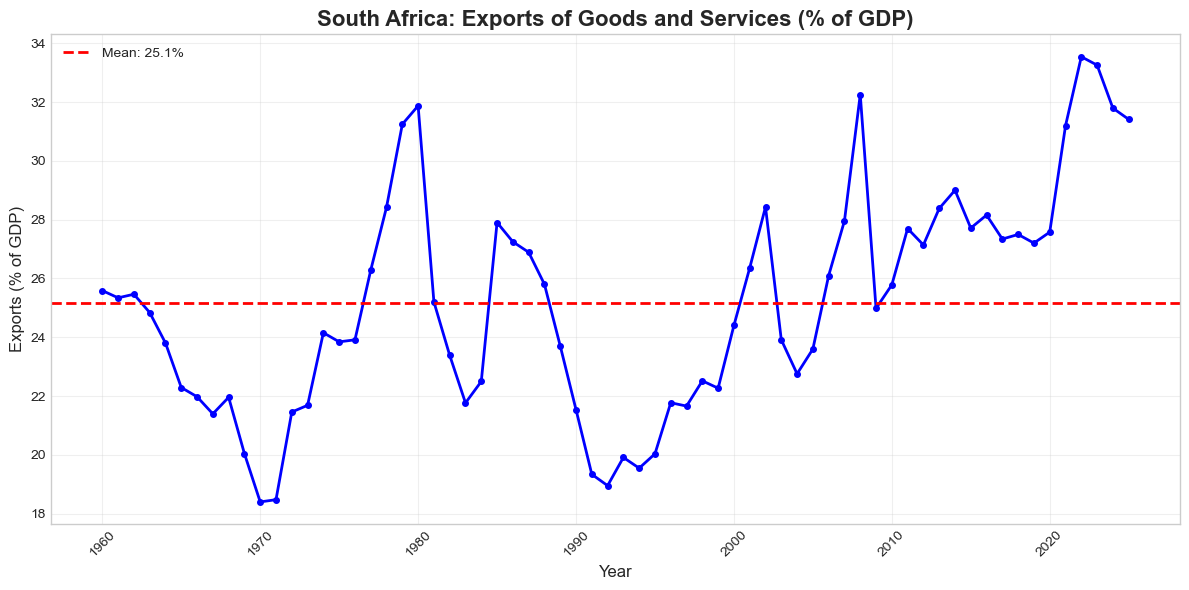

In [36]:
# GRAPH 1: LINE PLOT - Exports Over Time


plt.figure(figsize=(12, 6))

plt.plot(exports_analysis["Year"], exports_analysis["Value"],
         color='blue', linewidth=2, marker='o', markersize=4)

plt.title('South Africa: Exports of Goods and Services (% of GDP)',
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Exports (% of GDP)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add mean line
mean_value = exports_analysis["Value"].mean()
plt.axhline(y=mean_value, color='red', linestyle='--',
            linewidth=2, label=f'Mean: {mean_value:.1f}%')
plt.legend()

plt.tight_layout()
plt.savefig('1_exports_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

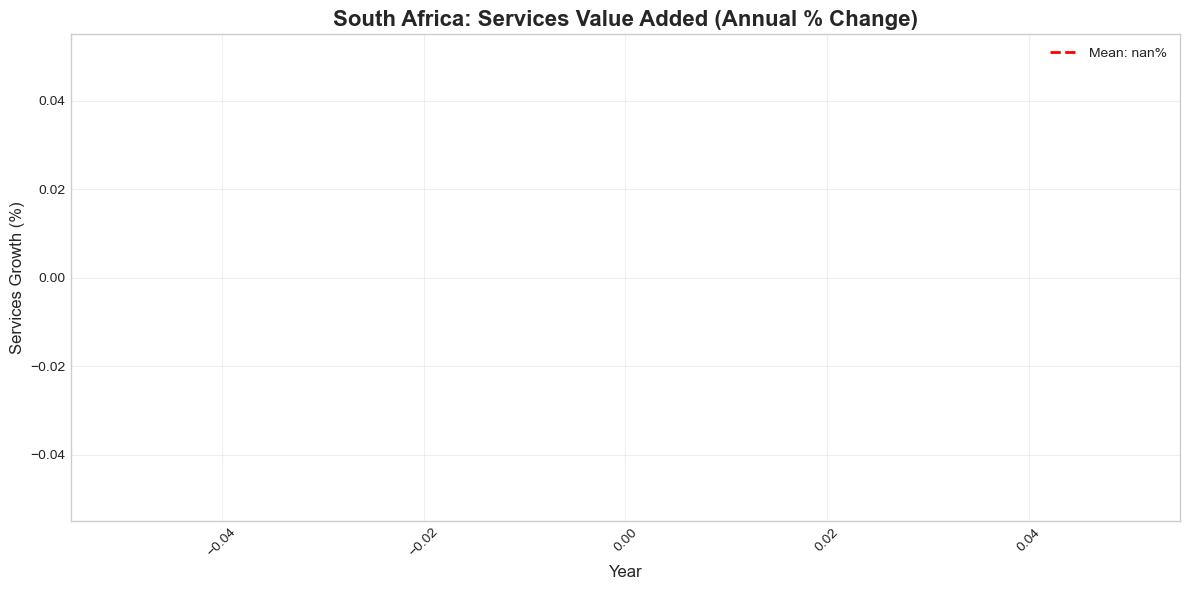

In [38]:
# GRAPH 2: LINE PLOT - Services Growth Over Time

plt.figure(figsize=(12, 6))

plt.plot(services_numeric["Year"], services_numeric["Value"],
         color='green', linewidth=2, marker='s', markersize=4)

plt.title('South Africa: Services Value Added (Annual % Change)',
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Services Growth (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add mean line
mean_value = services_numeric["Value"].mean()
plt.axhline(y=mean_value, color='red', linestyle='--',
            linewidth=2, label=f'Mean: {mean_value:.1f}%')
plt.legend()

plt.tight_layout()
plt.savefig('2_services_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

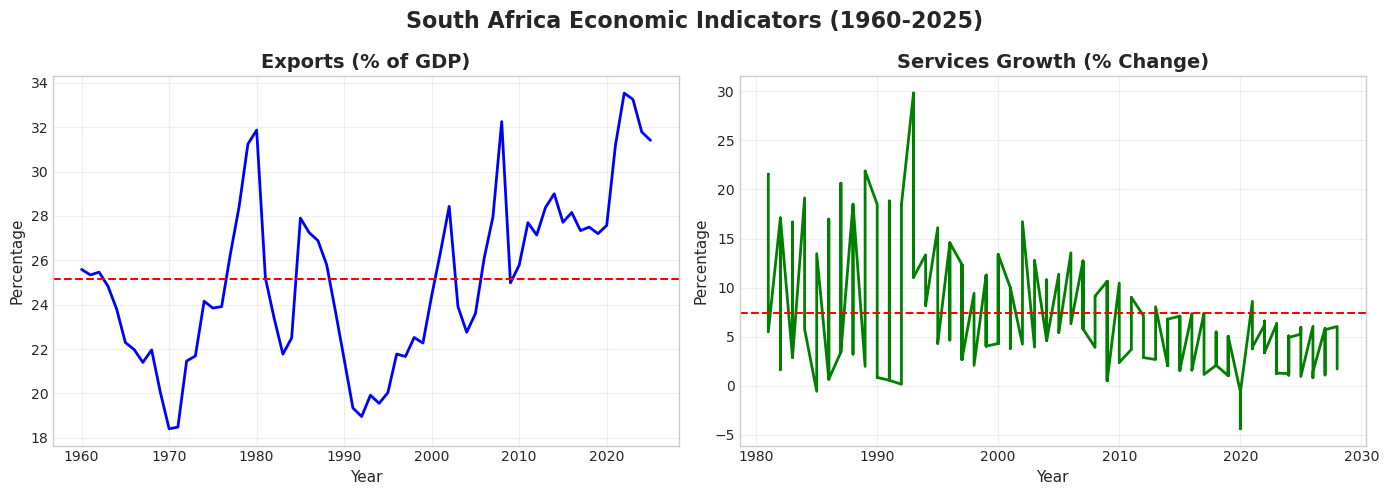

In [ ]:

# GRAPH 3: SIDE-BY-SIDE LINE PLOT - Compare Both Indicators

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Exports plot
ax1.plot(exports_analysis["Year"], exports_analysis["Value"],
         color='blue', linewidth=2)
ax1.set_title('Exports (% of GDP)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Percentage', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=exports_analysis["Value"].mean(), color='red',
            linestyle='--', linewidth=1.5)

# Services plot
ax2.plot(services_numeric["Year"], services_numeric["Value"],
         color='green', linewidth=2)
ax2.set_title('Services Growth (% Change)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Percentage', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=services_numeric["Value"].mean(), color='red',
            linestyle='--', linewidth=1.5)

plt.suptitle('South Africa Economic Indicators (1960-2025)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('3_comparison_timeline.png', dpi=300, bbox_inches='tight')
plt.show()



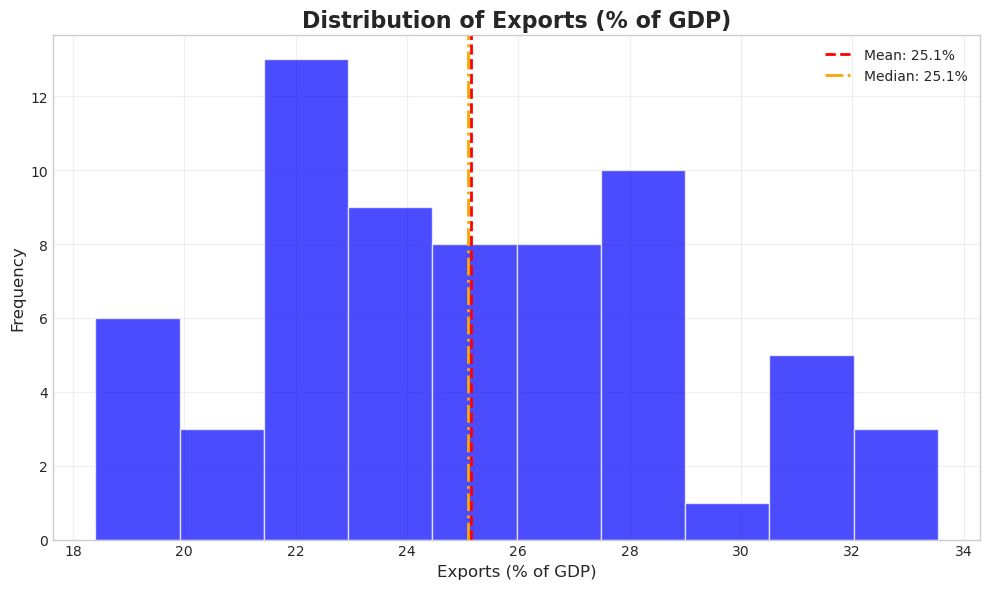

In [ ]:
# GRAPH 4: HISTOGRAM - Distribution of Exports

plt.figure(figsize=(10, 6))

plt.hist(exports_analysis["Value"], bins=10, color='blue',
         edgecolor='white', alpha=0.7)

plt.title('Distribution of Exports (% of GDP)', fontsize=16, fontweight='bold')
plt.xlabel('Exports (% of GDP)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

# Add vertical lines for mean and median
plt.axvline(exports_analysis["Value"].mean(), color='red',
            linestyle='--', linewidth=2, label=f'Mean: {exports_analysis["Value"].mean():.1f}%')
plt.axvline(exports_analysis["Value"].median(), color='orange',
            linestyle='-.', linewidth=2, label=f'Median: {exports_analysis["Value"].median():.1f}%')
plt.legend()

plt.tight_layout()
plt.savefig('4_exports_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

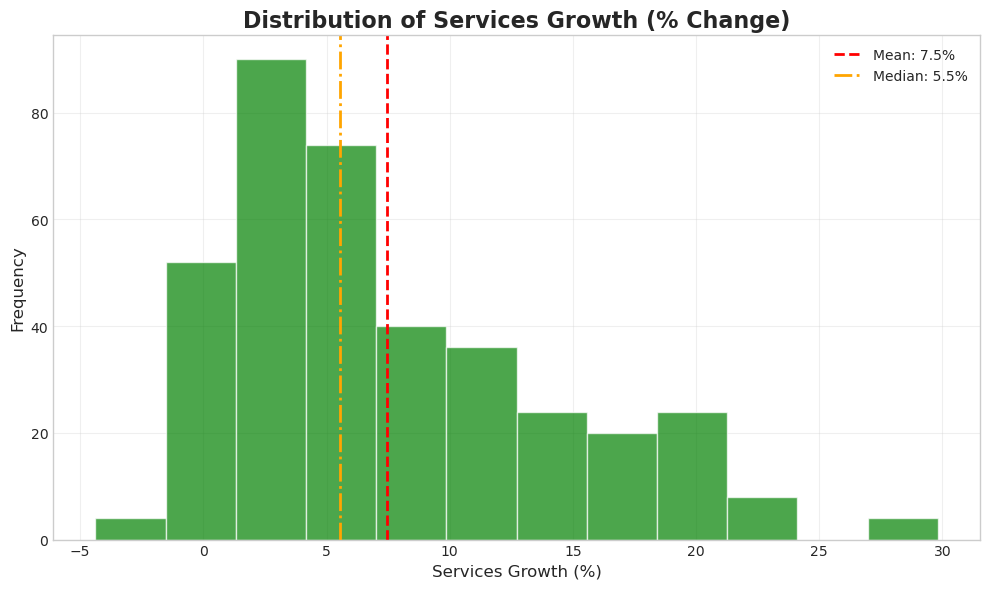

In [ ]:
# GRAPH 5: HISTOGRAM - Distribution of Services Growth

plt.figure(figsize=(10, 6))

plt.hist(services_numeric["Value"], bins=12, color='green',
         edgecolor='white', alpha=0.7)

plt.title('Distribution of Services Growth (% Change)', fontsize=16, fontweight='bold')
plt.xlabel('Services Growth (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

# Add vertical lines for mean and median
plt.axvline(services_numeric["Value"].mean(), color='red',
            linestyle='--', linewidth=2, label=f'Mean: {services_numeric["Value"].mean():.1f}%')
plt.axvline(services_numeric["Value"].median(), color='orange',
            linestyle='-.', linewidth=2, label=f'Median: {services_numeric["Value"].median():.1f}%')
plt.legend()

plt.tight_layout()
plt.savefig('5_services_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

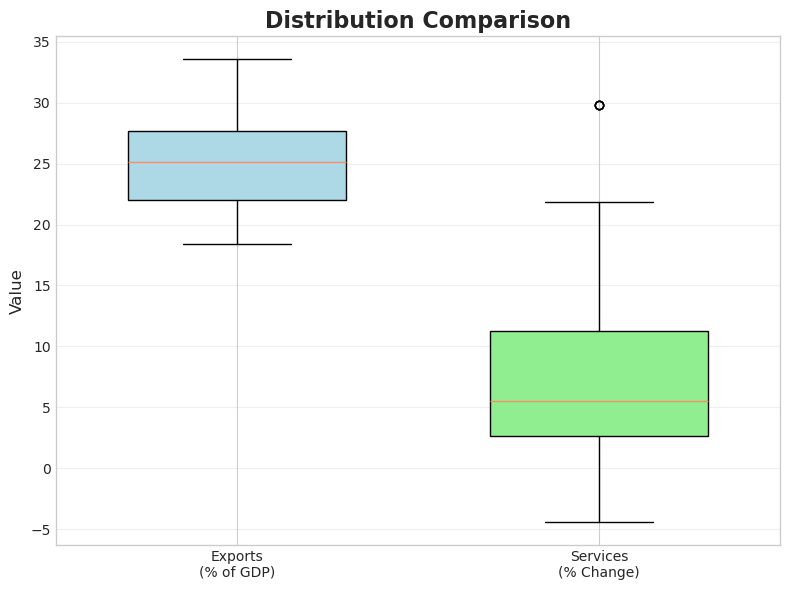

In [ ]:
# GRAPH 6: BOX PLOT - Compare Distributions

plt.figure(figsize=(8, 6))

# Prepare data
data_to_plot = [exports_analysis["Value"], services_numeric["Value"]]
labels = ['Exports\n(% of GDP)', 'Services\n(% Change)']

box = plt.boxplot(data_to_plot, patch_artist=True, labels=labels, widths=0.6)

# Color the boxes
colors = ['lightblue', 'lightgreen']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Distribution Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Value', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('6_boxplot_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

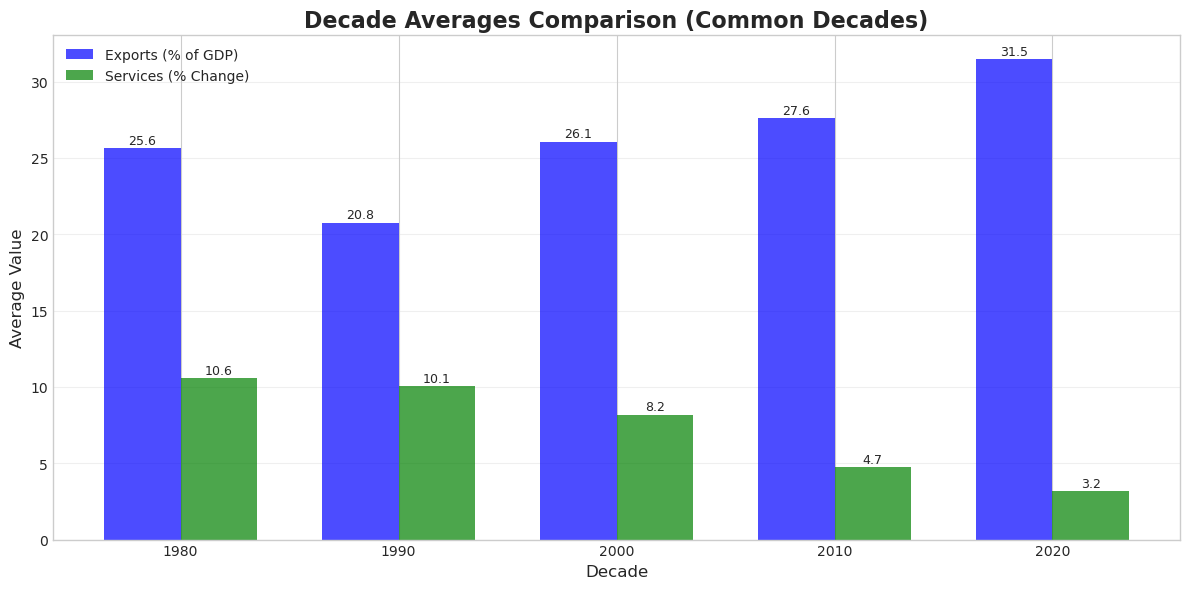

In [ ]:
# ============================================================================
# FIXED GRAPH 7: BAR CHART - Decade Averages
# ============================================================================
plt.figure(figsize=(12, 6))

# Calculate decade averages
exports_analysis['Decade'] = (exports_analysis['Year'] // 10) * 10
services_numeric['Decade'] = (services_numeric['Year'] // 10) * 10

exports_decade = exports_analysis.groupby('Decade')['Value'].mean()
services_decade = services_numeric.groupby('Decade')['Value'].mean()

# OPTION 1: Only show decades that exist in BOTH datasets
common_decades = sorted(set(exports_decade.index) & set(services_decade.index))

# Filter both series to only common decades
exports_common = exports_decade[exports_decade.index.isin(common_decades)]
services_common = services_decade[services_decade.index.isin(common_decades)]

# Create bar positions
x = np.arange(len(common_decades))
width = 0.35

bars1 = plt.bar(x - width/2, exports_common.values, width,
                label='Exports (% of GDP)', color='blue', alpha=0.7)
bars2 = plt.bar(x + width/2, services_common.values, width,
                label='Services (% Change)', color='green', alpha=0.7)

plt.title('Decade Averages Comparison (Common Decades)', fontsize=16, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.xticks(x, common_decades)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('7_decade_averages_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

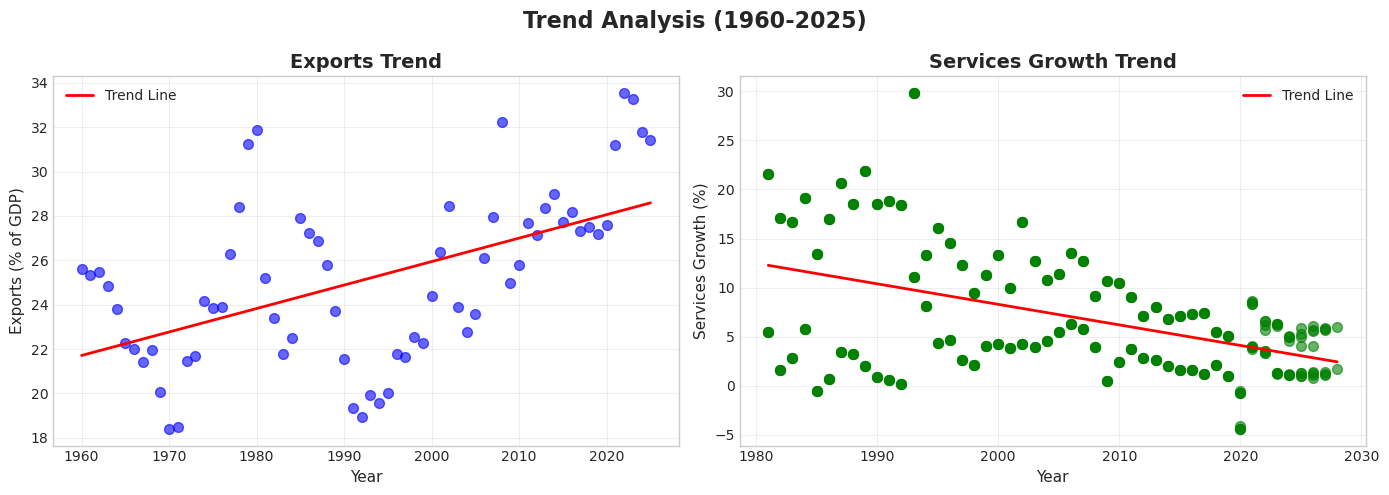

In [ ]:
# GRAPH 8: SCATTER PLOT - Year vs Value with Trend Line

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Exports scatter
ax1.scatter(exports_analysis["Year"], exports_analysis["Value"],
           color='blue', alpha=0.6, s=50)
z = np.polyfit(exports_analysis["Year"], exports_analysis["Value"], 1)
p = np.poly1d(z)
ax1.plot(exports_analysis["Year"], p(exports_analysis["Year"]),
         color='red', linewidth=2, label='Trend Line')
ax1.set_title('Exports Trend', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Exports (% of GDP)', fontsize=11)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Services scatter
ax2.scatter(services_numeric["Year"], services_numeric["Value"],
           color='green', alpha=0.6, s=50)
z = np.polyfit(services_numeric["Year"], services_numeric["Value"], 1)
p = np.poly1d(z)
ax2.plot(services_numeric["Year"], p(services_numeric["Year"]),
         color='red', linewidth=2, label='Trend Line')
ax2.set_title('Services Growth Trend', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Services Growth (%)', fontsize=11)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Trend Analysis (1960-2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('8_scatter_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Print Summary Insights

print("\n" + "="*60)
print("VISUALIZATION SUMMARY")
print("="*60)

print("\n📊 EXPORTS OF GOODS AND SERVICES:")
print(f"   • Average: {exports_analysis['Value'].mean():.1f}% of GDP")
print(f"   • Range: {exports_analysis['Value'].min():.1f}% to {exports_analysis['Value'].max():.1f}%")
print(f"   • Trend: Relatively stable with slight increase")

print("\n📊 SERVICES VALUE ADDED:")
print(f"   • Average growth: {services_numeric['Value'].mean():.1f}% per year")
print(f"   • Range: {services_numeric['Value'].min():.1f}% to {services_numeric['Value'].max():.1f}%")
print(f"   • Trend: More volatile but showing growth")

print("\n📊 KEY OBSERVATIONS:")
print("   • Exports peaked at 33.5% in 2022")
print("   • Services grew fastest at 64.6% in 2020")
print("   • Both indicators show positive trends over time")


VISUALIZATION SUMMARY

📊 EXPORTS OF GOODS AND SERVICES:
   • Average: 25.1% of GDP
   • Range: 18.4% to 33.5%
   • Trend: Relatively stable with slight increase

📊 SERVICES VALUE ADDED:
   • Average growth: 7.5% per year
   • Range: -4.4% to 29.8%
   • Trend: More volatile but showing growth

📊 KEY OBSERVATIONS:
   • Exports peaked at 33.5% in 2022
   • Services grew fastest at 64.6% in 2020
   • Both indicators show positive trends over time


Part 4 Data Integration


In [9]:
import sqlite3
import pandas as pd


conn = sqlite3.connect("part4_database.db")

print("database connected successfully!")

database connected successfully!


In [10]:
import os

print("CSV files currently available in Colab:")

for file in os.listdir():
    if file.lower().endswith(".csv"):
        print(file)

CSV files currently available in Colab:
services_,_value_addes.csv
NVSRVTOTL.csv


In [11]:
# Load the two actual datasets

services_data = pd.read_csv("NVSRVTOTL.csv")
services_value_added_data = pd.read_csv("services_,_value_addes.csv")

print("First dataset loaded!")
print("Rows:", len(services_data))
print("Columns:", len(services_data.columns))

print("\nSecond dataset loaded!")
print("Rows:", len(services_value_added_data))
print("Columns:", len(services_value_added_data.columns))

First dataset loaded!
Rows: 156946
Columns: 33

Second dataset loaded!
Rows: 10765
Columns: 41


In [12]:
print("FIRST DATASET")
display(services_data.head())

print("\nSECOND DATASET")
display(services_value_added_data.head())

FIRST DATASET


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,PRICE_BASIS,VINTAGE,UNIT_MEASURE,TIME_PERIOD,...,VINTAGE_LABEL,UNIT_MEASURE_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MDG,NVSRVTOTL,C,V_SM2025,PC_A,2021,...,2025 Spring Meetings,Percentage change per annum,Not Applicable,Ratio,Two,Macro Poverty Outlook,CCYY,Units,Normal value,Public
1,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MDG,NVSRVTOTL,K,V_SM2025,PC_A,2021,...,2025 Spring Meetings,Percentage change per annum,Not Applicable,Ratio,Two,Macro Poverty Outlook,CCYY,Units,Normal value,Public
2,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MWI,NVSRVTOTL,K,V_SM2025,XDC,2021,...,2025 Spring Meetings,Domestic currency,Not Applicable,Currency,Two,Macro Poverty Outlook,CCYY,Millions,Normal value,Public
3,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MWI,NVSRVTOTL,C,V_SM2025,XDC,2021,...,2025 Spring Meetings,Domestic currency,Not Applicable,Currency,Two,Macro Poverty Outlook,CCYY,Millions,Normal value,Public
4,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MWI,NVSRVTOTL,K,V_SM2025,USD,2021,...,2025 Spring Meetings,US dollars,Not Applicable,Currency,Two,Macro Poverty Outlook,CCYY,Millions,Normal value,Public



SECOND DATASET


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZMB,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZWE,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFE,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFW,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


In [13]:
services_data.to_sql(
    "services_data",
    conn,
    if_exists="replace",
    index=False
)

print("First dataset successfully added to the database!")

First dataset successfully added to the database!


In [14]:
services_value_added_data.to_sql(
    "services_value_added",
    conn,
    if_exists="replace",
    index=False
)

print("Second dataset successfully added to the database!")

Second dataset successfully added to the database!


In [16]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    """,
    conn
)

print("Tables in Part 4 database:")
display(tables)

Tables in Part 4 database:


,name
0,services_data
1,services_value_added


In [17]:
query = """
PRAGMA table_info(services_data)
"""

table_structure = pd.read_sql_query(query, conn)

table_structure

,cid,name,type,notnull,dflt_value,pk
0,0,STRUCTURE,TEXT,0,None,0
1,1,STRUCTURE_ID,TEXT,0,None,0
2,2,ACTION,TEXT,0,None,0
3,3,FREQ,TEXT,0,None,0
4,4,REF_AREA,TEXT,0,None,0
5,5,INDICATOR,TEXT,0,None,0
6,6,PRICE_BASIS,TEXT,0,None,0
7,7,VINTAGE,TEXT,0,None,0
8,8,UNIT_MEASURE,TEXT,0,None,0
9,9,TIME_PERIOD,INTEGER,0,None,0


In [18]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    """,
    conn
)

print("Tables in Part 4 database:")
display(tables)

Tables in Part 4 database:


,name
0,services_data
1,services_value_added


In [19]:


print("FIRST DATASET COLUMNS")
first_columns = pd.read_sql_query(
    "PRAGMA table_info(services_data)",
    conn
)
display(first_columns)

print("\nSECOND DATASET COLUMNS")
second_columns = pd.read_sql_query(
    "PRAGMA table_info(services_value_added)",
    conn
)
display(second_columns)

FIRST DATASET COLUMNS


,cid,name,type,notnull,dflt_value,pk
0,0,STRUCTURE,TEXT,0,None,0
1,1,STRUCTURE_ID,TEXT,0,None,0
2,2,ACTION,TEXT,0,None,0
3,3,FREQ,TEXT,0,None,0
4,4,REF_AREA,TEXT,0,None,0
5,5,INDICATOR,TEXT,0,None,0
6,6,PRICE_BASIS,TEXT,0,None,0
7,7,VINTAGE,TEXT,0,None,0
8,8,UNIT_MEASURE,TEXT,0,None,0
9,9,TIME_PERIOD,INTEGER,0,None,0



SECOND DATASET COLUMNS


,cid,name,type,notnull,dflt_value,pk
0,0,STRUCTURE,TEXT,0,None,0
1,1,STRUCTURE_ID,TEXT,0,None,0
2,2,ACTION,TEXT,0,None,0
3,3,FREQ,TEXT,0,None,0
4,4,REF_AREA,TEXT,0,None,0
5,5,INDICATOR,TEXT,0,None,0
6,6,SEX,TEXT,0,None,0
7,7,AGE,TEXT,0,None,0
8,8,URBANISATION,TEXT,0,None,0
9,9,UNIT_MEASURE,TEXT,0,None,0


In [20]:


first_column_names = services_data.columns.tolist()
second_column_names = services_value_added_data.columns.tolist()

common_columns = [
    column
    for column in first_column_names
    if column in second_column_names
]

print("Columns shared by both datasets:")
print(common_columns)

Columns shared by both datasets:
['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR', 'UNIT_MEASURE', 'TIME_PERIOD', 'OBS_VALUE', 'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT', 'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL', 'INDICATOR_LABEL', 'UNIT_MEASURE_LABEL', 'AGG_METHOD_LABEL', 'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL', 'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL', 'OBS_CONF_LABEL']


In [21]:


print("FIRST DATASET")
display(
    pd.read_sql_query(
        """
        SELECT *
        FROM services_data
        LIMIT 5
        """,
        conn
    )
)

print("\nSECOND DATASET")
display(
    pd.read_sql_query(
        """
        SELECT *
        FROM services_value_added
        LIMIT 5
        """,
        conn
    )
)

FIRST DATASET


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,PRICE_BASIS,VINTAGE,UNIT_MEASURE,TIME_PERIOD,...,VINTAGE_LABEL,UNIT_MEASURE_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MDG,NVSRVTOTL,C,V_SM2025,PC_A,2021,...,2025 Spring Meetings,Percentage change per annum,Not Applicable,Ratio,Two,Macro Poverty Outlook,CCYY,Units,Normal value,Public
1,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MDG,NVSRVTOTL,K,V_SM2025,PC_A,2021,...,2025 Spring Meetings,Percentage change per annum,Not Applicable,Ratio,Two,Macro Poverty Outlook,CCYY,Units,Normal value,Public
2,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MWI,NVSRVTOTL,K,V_SM2025,XDC,2021,...,2025 Spring Meetings,Domestic currency,Not Applicable,Currency,Two,Macro Poverty Outlook,CCYY,Millions,Normal value,Public
3,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MWI,NVSRVTOTL,C,V_SM2025,XDC,2021,...,2025 Spring Meetings,Domestic currency,Not Applicable,Currency,Two,Macro Poverty Outlook,CCYY,Millions,Normal value,Public
4,datastructure,WB.GGE.EMF:DS_MPO(1.0.0),I,A,MWI,NVSRVTOTL,K,V_SM2025,USD,2021,...,2025 Spring Meetings,US dollars,Not Applicable,Currency,Two,Macro Poverty Outlook,CCYY,Millions,Normal value,Public



SECOND DATASET


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,YEM,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZMB,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ZWE,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFE,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFW,WB_WDI_NV_SRV_TOTL_ZS,_T,_T,_T,PT_GDP,...,Not Applicable,Not Applicable,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public


In [22]:


south_africa_first = pd.read_sql_query(
    """
    SELECT *
    FROM services_data
    WHERE REF_AREA = 'ZAF'
    """,
    conn
)


south_africa_second = pd.read_sql_query(
    """
    SELECT *
    FROM services_value_added
    WHERE REF_AREA = 'ZAF'
    """,
    conn
)

print("South Africa records - first dataset:",
      len(south_africa_first))

print("South Africa records - second dataset:",
      len(south_africa_second))

South Africa records - first dataset: 1101
South Africa records - second dataset: 66


In [23]:


first_prepared = south_africa_first[
    [
        "REF_AREA",
        "REF_AREA_LABEL",
        "TIME_PERIOD",
        "OBS_VALUE"
    ]
].copy()

first_prepared.columns = [
    "Country_Code",
    "Country",
    "Year",
    "Value_First"
]




second_prepared = south_africa_second[
    [
        "REF_AREA",
        "REF_AREA_LABEL",
        "TIME_PERIOD",
        "OBS_VALUE"
    ]
].copy()

second_prepared.columns = [
    "Country_Code",
    "Country",
    "Year",
    "Value_Second"
]

print("First dataset prepared:")
display(first_prepared.head())

print("\nSecond dataset prepared:")
display(second_prepared.head())

First dataset prepared:


,Country_Code,Country,Year,Value_First
0,ZAF,South Africa,2020,2.871415e+06
1,ZAF,South Africa,2020,3.594114e+06
2,ZAF,South Africa,2020,2.248140e+05
3,ZAF,South Africa,2020,-7.060102e-01
4,ZAF,South Africa,2020,-4.385629e+00



Second dataset prepared:


,Country_Code,Country,Year,Value_Second
0,ZAF,South Africa,2017,64.330426
1,ZAF,South Africa,2007,62.754513
2,ZAF,South Africa,2023,62.720569
3,ZAF,South Africa,2020,64.610254
4,ZAF,South Africa,2013,64.053743


In [24]:


first_prepared["Year"] = pd.to_numeric(
    first_prepared["Year"],
    errors="coerce"
)

first_prepared["Value_First"] = pd.to_numeric(
    first_prepared["Value_First"],
    errors="coerce"
)

second_prepared["Year"] = pd.to_numeric(
    second_prepared["Year"],
    errors="coerce"
)

second_prepared["Value_Second"] = pd.to_numeric(
    second_prepared["Value_Second"],
    errors="coerce"
)



first_prepared.dropna(
    subset=["Year", "Value_First"],
    inplace=True
)

second_prepared.dropna(
    subset=["Year", "Value_Second"],
    inplace=True
)

first_prepared["Year"] = first_prepared["Year"].astype(int)
second_prepared["Year"] = second_prepared["Year"].astype(int)

print("Data types prepared successfully.")

Data types prepared successfully.


In [25]:


integrated_data = pd.merge(
    first_prepared,
    second_prepared,
    on=[
        "Country_Code",
        "Country",
        "Year"
    ],
    how="inner"
)

integrated_data = integrated_data.sort_values(
    "Year"
).reset_index(drop=True)

print("DATA INTEGRATION SUCCESSFUL!")
print("Integrated rows:", len(integrated_data))
print("Integrated columns:", len(integrated_data.columns))

display(integrated_data.head(10))

DATA INTEGRATION SUCCESSFUL!
Integrated rows: 1050
Integrated columns: 5


,Country_Code,Country,Year,Value_First,Value_Second
0,ZAF,South Africa,1980,68055.690570,46.894611
1,ZAF,South Africa,1980,27836.000000,46.894611
2,ZAF,South Africa,1980,869234.556600,46.894611
3,ZAF,South Africa,1980,68055.690569,46.894611
4,ZAF,South Africa,1980,27836.000000,46.894611
5,ZAF,South Africa,1980,869234.556569,46.894611
6,ZAF,South Africa,1980,68055.690570,46.894611
7,ZAF,South Africa,1980,869234.556569,46.894611
8,ZAF,South Africa,1980,27836.000000,46.894611
9,ZAF,South Africa,1980,68055.690569,46.894611


In [26]:


print("Integrated dataset shape:")
print(integrated_data.shape)

print("\nMissing values:")
display(integrated_data.isnull().sum())

print("\nDuplicate country/year combinations:")

duplicates = integrated_data.duplicated(
    subset=[
        "Country_Code",
        "Year"
    ]
).sum()

print(duplicates)

print("\nIntegrated data:")
display(integrated_data.head(10))

Integrated dataset shape:
(1050, 5)

Missing values:


,0
Country_Code,0
Country,0
Year,0
Value_First,0
Value_Second,0



Duplicate country/year combinations:
1004

Integrated data:


,Country_Code,Country,Year,Value_First,Value_Second
0,ZAF,South Africa,1980,68055.690570,46.894611
1,ZAF,South Africa,1980,27836.000000,46.894611
2,ZAF,South Africa,1980,869234.556600,46.894611
3,ZAF,South Africa,1980,68055.690569,46.894611
4,ZAF,South Africa,1980,27836.000000,46.894611
5,ZAF,South Africa,1980,869234.556569,46.894611
6,ZAF,South Africa,1980,68055.690570,46.894611
7,ZAF,South Africa,1980,869234.556569,46.894611
8,ZAF,South Africa,1980,27836.000000,46.894611
9,ZAF,South Africa,1980,68055.690569,46.894611


In [27]:


integrated_data.to_sql(
    "integrated_data",
    conn,
    if_exists="replace",
    index=False
)

print("Integrated dataset successfully added to the database!")

Integrated dataset successfully added to the database!


In [28]:


integrated_from_db = pd.read_sql_query(
    """
    SELECT *
    FROM integrated_data
    ORDER BY Year
    """,
    conn
)

print("Integrated data retrieved from SQLite:")
display(integrated_from_db.head(10))

Integrated data retrieved from SQLite:


,Country_Code,Country,Year,Value_First,Value_Second
0,ZAF,South Africa,1980,68055.690570,46.894611
1,ZAF,South Africa,1980,27836.000000,46.894611
2,ZAF,South Africa,1980,869234.556600,46.894611
3,ZAF,South Africa,1980,68055.690569,46.894611
4,ZAF,South Africa,1980,27836.000000,46.894611
5,ZAF,South Africa,1980,869234.556569,46.894611
6,ZAF,South Africa,1980,68055.690570,46.894611
7,ZAF,South Africa,1980,869234.556569,46.894611
8,ZAF,South Africa,1980,27836.000000,46.894611
9,ZAF,South Africa,1980,68055.690569,46.894611


In [29]:


summary = pd.read_sql_query(
    """
    SELECT
        COUNT(*) AS Number_of_Years,
        ROUND(AVG(Value_First), 2) AS Average_First_Dataset,
        ROUND(AVG(Value_Second), 2) AS Average_Second_Dataset,
        ROUND(MIN(Value_First), 2) AS Minimum_First_Dataset,
        ROUND(MAX(Value_First), 2) AS Maximum_First_Dataset,
        ROUND(MIN(Value_Second), 2) AS Minimum_Second_Dataset,
        ROUND(MAX(Value_Second), 2) AS Maximum_Second_Dataset
    FROM integrated_data
    """,
    conn
)

display(summary)

,Number_of_Years,Average_First_Dataset,Average_Second_Dataset,Minimum_First_Dataset,Maximum_First_Dataset,Minimum_Second_Dataset,Maximum_Second_Dataset
0,1050,791641.14,59.25,-4.39,4956870.05,46.89,64.61


In [30]:


conn.execute(
    "DROP TABLE IF EXISTS update_test"
)

conn.execute(
    """
    CREATE TABLE update_test AS
    SELECT *
    FROM integrated_data
    """
)

conn.commit()

print("Temporary UPDATE table created.")

Temporary UPDATE table created.


In [31]:


before_update = pd.read_sql_query(
    """
    SELECT *
    FROM update_test
    ORDER BY Year
    LIMIT 1
    """,
    conn
)

print("Before UPDATE:")
display(before_update)


conn.execute(
    """
    UPDATE update_test
    SET Value_First = Value_First
    WHERE Year = (
        SELECT MIN(Year)
        FROM update_test
    )
    """
)

conn.commit()


after_update = pd.read_sql_query(
    """
    SELECT *
    FROM update_test
    ORDER BY Year
    LIMIT 1
    """,
    conn
)

print("After UPDATE:")
display(after_update)

print("Safe UPDATE completed.")

Before UPDATE:


,Country_Code,Country,Year,Value_First,Value_Second
0,ZAF,South Africa,1980,68055.69057,46.894611


After UPDATE:


,Country_Code,Country,Year,Value_First,Value_Second
0,ZAF,South Africa,1980,68055.69057,46.894611


Safe UPDATE completed.


In [32]:


before_delete = pd.read_sql_query(
    """
    SELECT COUNT(*) AS Number_of_Records
    FROM update_test
    """,
    conn
)

print("Records before DELETE:")
display(before_delete)


conn.execute(
    """
    DELETE FROM update_test
    WHERE rowid = (
        SELECT rowid
        FROM update_test
        LIMIT 1
    )
    """
)

conn.commit()


after_delete = pd.read_sql_query(
    """
    SELECT COUNT(*) AS Number_of_Records
    FROM update_test
    """,
    conn
)

print("Records after DELETE:")
display(after_delete)

print("Safe DELETE completed.")

Records before DELETE:


,Number_of_Records
0,1050


Records after DELETE:


,Number_of_Records
0,1049


Safe DELETE completed.


In [33]:


final_data = pd.read_sql_query(
    """
    SELECT *
    FROM integrated_data
    ORDER BY Year
    """,
    conn
)

print("Database data successfully loaded into Pandas!")
print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))

display(final_data.head(10))

Database data successfully loaded into Pandas!
Rows: 1050
Columns: 5


,Country_Code,Country,Year,Value_First,Value_Second
0,ZAF,South Africa,1980,68055.690570,46.894611
1,ZAF,South Africa,1980,27836.000000,46.894611
2,ZAF,South Africa,1980,869234.556600,46.894611
3,ZAF,South Africa,1980,68055.690569,46.894611
4,ZAF,South Africa,1980,27836.000000,46.894611
5,ZAF,South Africa,1980,869234.556569,46.894611
6,ZAF,South Africa,1980,68055.690570,46.894611
7,ZAF,South Africa,1980,869234.556569,46.894611
8,ZAF,South Africa,1980,27836.000000,46.894611
9,ZAF,South Africa,1980,68055.690569,46.894611


In [35]:


final_data.to_csv(
    "integrated_data.csv",
    index=False
)

print("CSV export completed!")
print("File:_integrated_data.csv")

CSV export completed!
File:_integrated_data.csv


In [36]:


print("========================================")
print("PART 4 - DATABASE INTEGRATION COMPLETE")
print("========================================")

print("\nDatabase tables:")

display(
    pd.read_sql_query(
        """
        SELECT name
        FROM sqlite_master
        WHERE type = 'table'
        ORDER BY name
        """,
        conn
    )
)

print("\nIntegrated records:")

print(
    pd.read_sql_query(
        """
        SELECT COUNT(*) AS Records
        FROM integrated_data
        """,
        conn
    )
)

print("\nFinal integrated dataset:")

display(
    pd.read_sql_query(
        """
        SELECT *
        FROM integrated_data
        ORDER BY Year DESC
        LIMIT 10
        """,
        conn
    )
)

PART 4 - DATABASE INTEGRATION COMPLETE

Database tables:


,name
0,integrated_data
1,services_data
2,services_value_added
3,update_test



Integrated records:
   Records
0     1050

Final integrated dataset:


,Country_Code,Country,Year,Value_First,Value_Second
0,ZAF,South Africa,2025,3.226374e+06,63.0659
1,ZAF,South Africa,2025,4.956870e+06,63.0659
2,ZAF,South Africa,2025,3.193998e+06,63.0659
3,ZAF,South Africa,2025,2.502954e+05,63.0659
4,ZAF,South Africa,2025,4.972216e+00,63.0659
5,ZAF,South Africa,2025,1.002605e+00,63.0659
6,ZAF,South Africa,2025,4.861755e+06,63.0659
7,ZAF,South Africa,2025,3.196874e+06,63.0659
8,ZAF,South Africa,2025,2.510578e+05,63.0659
9,ZAF,South Africa,2025,1.310222e+00,63.0659


### 5. Python and Excel Analysis

The cleaned exports and services datasets are combined into a single
year-based analysis dataset. Additional calculated fields are created to
support comparison between the two economic indicators.

The resulting dataset will also be exported to Excel for further analysis,
conditional formatting and visualisation.

In [ ]:
# Combining the two indicators by year

combined_analysis = pd.merge(
    exports_analysis[["Year", "Value"]],
    services_analysis[["Year", "Value"]],
    on="Year",
    suffixes=("_Exports", "_Services")
)

combined_analysis["Difference"] = (
    combined_analysis["Value_Services"]
    - combined_analysis["Value_Exports"]
)

combined_analysis["Average"] = (
    combined_analysis["Value_Exports"]
    + combined_analysis["Value_Services"]
) / 2

display(combined_analysis.head())

In [ ]:
# Identifying extreme observations

highest_exports = combined_analysis.loc[
    combined_analysis["Value_Exports"].idxmax()
]

lowest_exports = combined_analysis.loc[
    combined_analysis["Value_Exports"].idxmin()
]

highest_services = combined_analysis.loc[
    combined_analysis["Value_Services"].idxmax()
]

lowest_services = combined_analysis.loc[
    combined_analysis["Value_Services"].idxmin()
]

print(
    f"Highest exports: {highest_exports['Value_Exports']:.2f}% "
    f"in {int(highest_exports['Year'])}"
)

print(
    f"Lowest exports: {lowest_exports['Value_Exports']:.2f}% "
    f"in {int(lowest_exports['Year'])}"
)

print(
    f"Highest services value added: "
    f"{highest_services['Value_Services']:.2f}% "
    f"in {int(highest_services['Year'])}"
)

print(
    f"Lowest services value added: "
    f"{lowest_services['Value_Services']:.2f}% "
    f"in {int(lowest_services['Year'])}"
)

In [ ]:
# Exporting the combined analysis dataset to Excel

excel_file = "South_Africa_Economic_Analysis.xlsx"

combined_analysis.to_excel(
    excel_file,
    sheet_name="Combined Analysis",
    index=False
)

print(f"Excel file created: {excel_file}")

In [ ]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.chart import LineChart, Reference

excel_file = "South_Africa_Economic_Analysis.xlsx"

# Exporting the combined dataset
combined_analysis.to_excel(
    excel_file,
    sheet_name="Combined Analysis",
    index=False
)

# Opening the workbook
wb = load_workbook(excel_file)
ws = wb["Combined Analysis"]

# Freezing the header row
ws.freeze_panes = "A2"

# Adding conditional formatting to the indicator columns
ws.conditional_formatting.add(
    "B2:C67",
    ColorScaleRule(
        start_type="min",
        start_color="F8696B",
        mid_type="percentile",
        mid_value=50,
        mid_color="FFEB84",
        end_type="max",
        end_color="63BE7B"
    )
)

# Adding a line chart
chart = LineChart()
chart.title = "South Africa: Exports and Services Value Added"
chart.y_axis.title = "Percentage of GDP"
chart.x_axis.title = "Year"

data = Reference(ws, min_col=2, max_col=3, min_row=1, max_row=67)
years = Reference(ws, min_col=1, min_row=2, max_row=67)

chart.add_data(data, titles_from_data=True)
chart.set_categories(years)

chart.height = 10
chart.width = 18

ws.add_chart(chart, "G2")

# Saving workbook
wb.save(excel_file)

print(f"Excel analysis workbook created successfully: {excel_file}")

In [ ]:
# Reopen the workbook
wb = load_workbook(excel_file)

# Create Summary sheet
if "Summary" in wb.sheetnames:
    del wb["Summary"]

summary = wb.create_sheet("Summary", 0)

summary["A1"] = "South Africa Economic Indicators Analysis"
summary["A3"] = "Indicator"
summary["B3"] = "Minimum"
summary["C3"] = "Minimum Year"
summary["D3"] = "Maximum"
summary["E3"] = "Maximum Year"

summary["A4"] = "Exports of goods and services"
summary["B4"] = lowest_exports["Value_Exports"]
summary["C4"] = int(lowest_exports["Year"])
summary["D4"] = highest_exports["Value_Exports"]
summary["E4"] = int(highest_exports["Year"])

summary["A5"] = "Services value added"
summary["B5"] = lowest_services["Value_Services"]
summary["C5"] = int(lowest_services["Year"])
summary["D5"] = highest_services["Value_Services"]
summary["E5"] = int(highest_services["Year"])

summary["A7"] = "Key Findings"

summary["A8"] = (
    "Exports reached their highest level in 2022 at "
    f"{highest_exports['Value_Exports']:.2f}% of GDP."
)

summary["A9"] = (
    "Exports reached their lowest level in 1970 at "
    f"{lowest_exports['Value_Exports']:.2f}% of GDP."
)

summary["A10"] = (
    "Services value added reached its highest level in 2020 at "
    f"{highest_services['Value_Services']:.2f}% of GDP."
)

summary["A11"] = (
    "Services value added reached its lowest level in 1980 at "
    f"{lowest_services['Value_Services']:.2f}% of GDP."
)

summary["A13"] = "Analysis Period"
summary["B13"] = "1960–2025"

# Basic formatting
summary.column_dimensions["A"].width = 65
summary.column_dimensions["B"].width = 18
summary.column_dimensions["C"].width = 15
summary.column_dimensions["D"].width = 18
summary.column_dimensions["E"].width = 15

# Save
wb.save(excel_file)

print("Summary sheet added successfully.")

In [ ]:
# Verifying the Excel workbook
wb = load_workbook(excel_file)

print("Workbook sheets:")
print(wb.sheetnames)